# Startup Success Prediction
End-to-end ML pipeline: cleaning → EDA → feature engineering → modeling → evaluation.

## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/startup_data.csv')
print(df.shape)
df.head()

(923, 49)


,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,...,c:65806,1,1,0,0,0,0,1.0000,1,closed


## 2. Data Cleaning & Preprocessing

In [2]:
# Target leak check: 'labels' is a 1:1 encoding of 'status' (1=acquired, 0=closed)
print(pd.crosstab(df['labels'], df['status']))

status  acquired  closed
labels                  
0              0     326
1            597       0


In [3]:
# Drop identifier / leakage / redundant columns
drop_cols = [
    'Unnamed: 0', 'id', 'object_id',      # identifiers
    'Unnamed: 6',                          # mostly empty, redundant with city
    'state_code.1',                        # duplicate of state_code
    'zip_code', 'latitude', 'longitude',   # granular location, city/state already captured
    'name', 'city',                        # high-cardinality identifiers
    'closed_at',                           # only present for closed startups -> direct leak
    'status',                              # replaced by clean 'labels' target
]
df_clean = df.drop(columns=drop_cols)
print(df_clean.shape)
df_clean.head()

(923, 37)


,state_code,labels,founded_at,first_funding_at,last_funding_at,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,...,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500
0,CA,1,1/1/2007,4/1/2009,1/1/2010,2.2493,3.0027,4.6685,6.7041,3,...,0,1,0,1,0,0,0,0,1.0000,0
1,CA,1,1/1/2000,2/14/2005,12/28/2009,5.1260,9.9973,7.0055,7.0055,9,...,0,0,1,0,0,1,1,1,4.7500,1
2,CA,1,3/18/2009,3/30/2010,3/30/2010,1.0329,1.0329,1.4575,2.2055,5,...,0,0,0,0,1,0,0,0,4.0000,1
3,CA,1,1/1/2002,2/17/2005,4/25/2007,3.1315,5.3151,6.0027,6.0027,5,...,0,0,0,0,0,1,1,1,3.3333,1
4,CA,0,8/1/2010,8/1/2010,4/1/2012,0.0000,1.6685,0.0384,0.0384,2,...,0,0,1,1,0,0,0,0,1.0000,1


In [4]:
# Parse date columns into datetime, then engineer age/duration features instead of raw dates
date_cols = ['founded_at', 'first_funding_at', 'last_funding_at']
for c in date_cols:
    df_clean[c] = pd.to_datetime(df_clean[c])

df_clean[date_cols].describe()

,founded_at,first_funding_at,last_funding_at
count,923,923,923
mean,2005-09-10 00:57:43.488624,2007-12-05 01:05:31.527627,2009-08-15 00:31:12.156013
min,1984-01-01 00:00:00,2000-01-01 00:00:00,2001-01-01 00:00:00
25%,2003-01-01 00:00:00,2006-03-01 00:00:00,2008-01-01 00:00:00
50%,2006-01-01 00:00:00,2007-09-01 00:00:00,2009-12-16 00:00:00
75%,2008-04-01 00:00:00,2009-11-01 00:00:00,2011-04-29 00:00:00
max,2013-04-16 00:00:00,2013-11-20 00:00:00,2013-11-20 00:00:00


In [5]:
# Missing value check on the cleaned frame
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

age_first_milestone_year    152
age_last_milestone_year     152
dtype: int64

In [6]:
# age_first_milestone_year / age_last_milestone_year missing = startup never hit a milestone.
# Impute with 0 (no milestone reached) rather than mean, since missingness itself is informative.
df_clean['age_first_milestone_year'] = df_clean['age_first_milestone_year'].fillna(0)
df_clean['age_last_milestone_year'] = df_clean['age_last_milestone_year'].fillna(0)

df_clean.isnull().sum().sum()  # should be 0 now

np.int64(0)

In [7]:
# Sanity check: negative ages shouldn't exist (funding/milestone before founding is a data artifact)
age_cols = ['age_first_funding_year', 'age_last_funding_year',
            'age_first_milestone_year', 'age_last_milestone_year']
df_clean[age_cols].describe()

,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year
count,923.000000,923.000000,923.000000,923.000000
mean,2.235630,3.931456,2.552196,3.971462
std,2.510449,2.967910,2.947421,3.424843
min,-9.046600,-9.046600,-14.169900,-7.005500
25%,0.576700,1.669850,0.000000,1.000000
50%,1.446600,3.528800,2.000000,3.783600
75%,3.575350,5.560250,4.002700,6.039750
max,21.895900,21.895900,24.684900,24.684900


In [8]:
# Clip small negative artifacts to 0 (a handful of rows have tiny negative ages from data entry noise)
for c in age_cols:
    df_clean[c] = df_clean[c].clip(lower=0)

df_clean[age_cols].describe()

,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year
count,923.000000,923.000000,923.000000,923.000000
mean,2.269952,3.947354,2.624127,3.997978
std,2.454950,2.930367,2.816093,3.378269
min,0.000000,0.000000,0.000000,0.000000
25%,0.576700,1.669850,0.000000,1.000000
50%,1.446600,3.528800,2.000000,3.783600
75%,3.575350,5.560250,4.002700,6.039750
max,21.895900,21.895900,24.684900,24.684900


## 3. Exploratory Data Analysis (EDA)

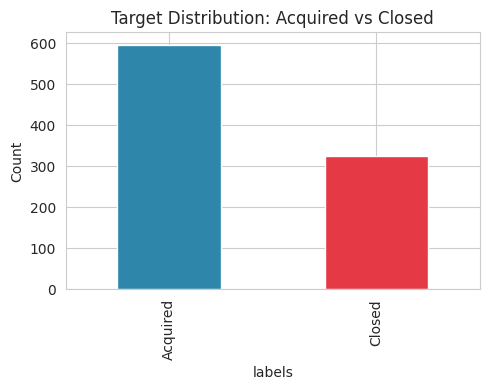

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(5,4))
df_clean['labels'].value_counts().rename({1:'Acquired', 0:'Closed'}).plot(kind='bar', color=['#2E86AB','#E63946'], ax=ax)
ax.set_title('Target Distribution: Acquired vs Closed')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../notebooks/eda_target_distribution.png', dpi=120)
plt.show()

/tmp/ipykernel_679/1118278842.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Closed','Acquired'])
/tmp/ipykernel_679/1118278842.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Closed','Acquired'])


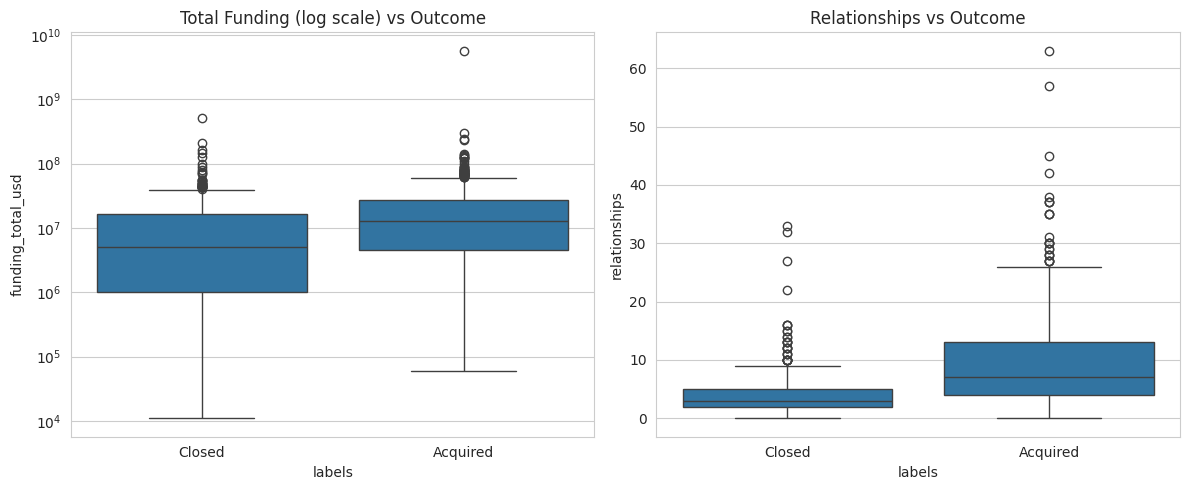

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df_clean, x='labels', y='funding_total_usd', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Total Funding (log scale) vs Outcome')
axes[0].set_xticklabels(['Closed','Acquired'])

sns.boxplot(data=df_clean, x='labels', y='relationships', ax=axes[1])
axes[1].set_title('Relationships vs Outcome')
axes[1].set_xticklabels(['Closed','Acquired'])
plt.tight_layout()
plt.savefig('../notebooks/eda_funding_relationships.png', dpi=120)
plt.show()

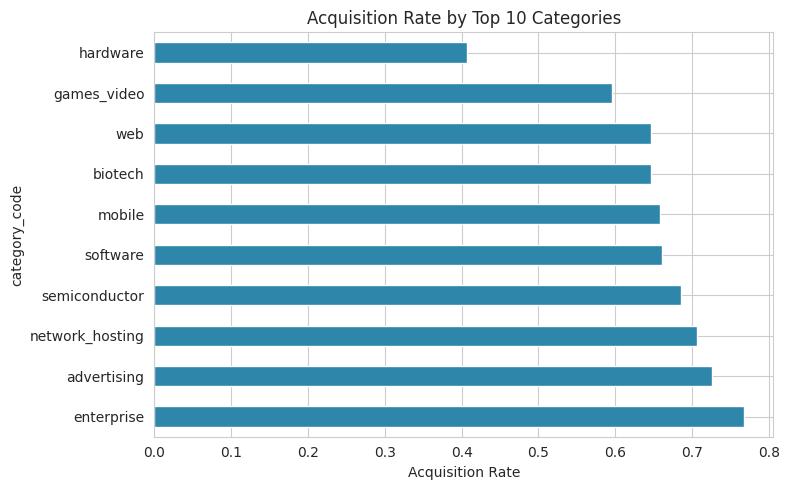

In [11]:
top_cats = df_clean['category_code'].value_counts().head(10).index
sub = df_clean[df_clean['category_code'].isin(top_cats)]
success_rate = sub.groupby('category_code')['labels'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
success_rate.plot(kind='barh', color='#2E86AB', ax=ax)
ax.set_xlabel('Acquisition Rate')
ax.set_title('Acquisition Rate by Top 10 Categories')
plt.tight_layout()
plt.savefig('../notebooks/eda_category_success.png', dpi=120)
plt.show()

In [12]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr = df_clean[numeric_cols].corr()['labels'].sort_values(ascending=False)
corr

labels                      1.000000
relationships               0.360434
age_last_milestone_year     0.359238
milestones                  0.328260
is_top500                   0.310652
age_first_milestone_year    0.257386
has_roundB                  0.208257
funding_rounds              0.206049
avg_participants            0.185992
has_roundA                  0.184307
has_roundC                  0.165902
has_roundD                  0.139940
is_MA                       0.081735
is_CA                       0.077217
is_enterprise               0.073772
age_last_funding_year       0.067870
is_NY                       0.059996
is_advertising              0.044355
funding_total_usd           0.040176
is_software                 0.012429
is_mobile                   0.007312
is_consulting               0.002373
is_biotech                  0.000104
is_web                     -0.000873
is_gamesvideo              -0.025893
is_othercategory           -0.042408
is_TX                      -0.045309
h

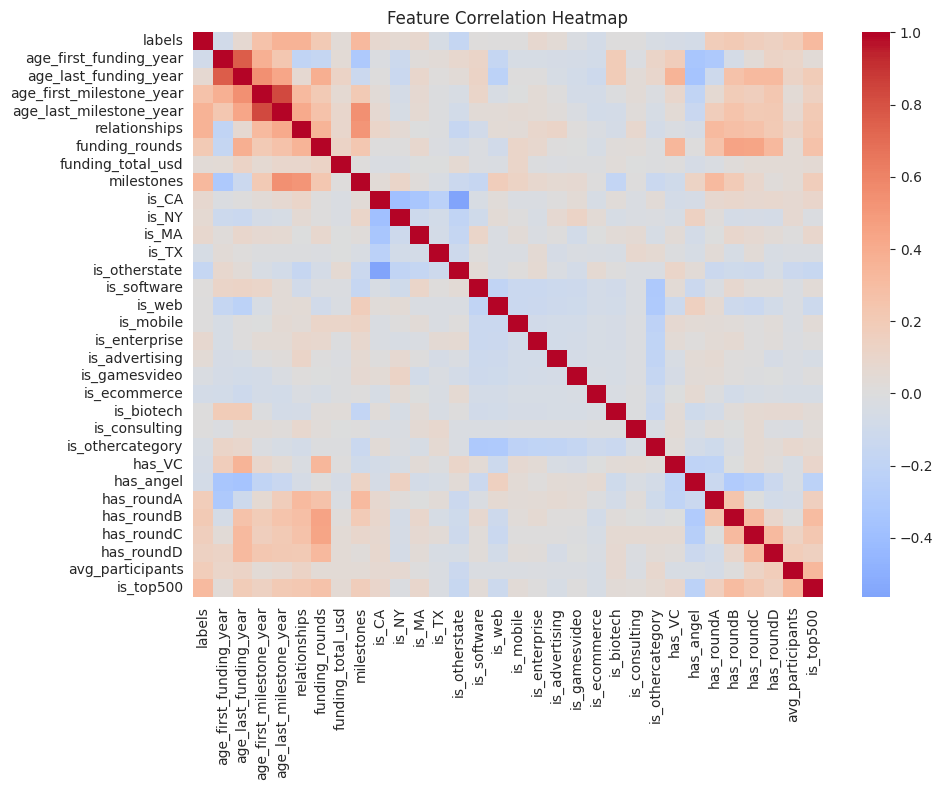

In [13]:
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(df_clean[numeric_cols].corr(), cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../notebooks/eda_correlation_heatmap.png', dpi=120)
plt.show()

## 4. Feature Engineering

In [14]:
# Duration-based features from raw dates
df_clean['funding_duration_days'] = (df_clean['last_funding_at'] - df_clean['first_funding_at']).dt.days
df_clean['funding_duration_days'] = df_clean['funding_duration_days'].clip(lower=0)

df_clean[['funding_duration_days']].describe()

,funding_duration_days
count,923.000000
mean,618.976165
std,706.833605
min,0.000000
25%,0.000000
50%,396.000000
75%,1020.000000
max,3949.000000


In [15]:
# Funding efficiency: total funding raised per relationship (network) -- proxy for capital efficiency
df_clean['funding_per_relationship'] = df_clean['funding_total_usd'] / (df_clean['relationships'] + 1)

# Milestone velocity: milestones achieved per year of operation up to last milestone
df_clean['milestone_velocity'] = df_clean['milestones'] / (df_clean['age_last_milestone_year'] + 1)

# Total number of funding round types secured (VC, angel, A, B, C, D) -- breadth of investor backing
round_flags = ['has_VC','has_angel','has_roundA','has_roundB','has_roundC','has_roundD']
df_clean['total_round_types'] = df_clean[round_flags].sum(axis=1)

df_clean[['funding_per_relationship','milestone_velocity','total_round_types']].describe()

,funding_per_relationship,milestone_velocity,total_round_types
count,9.230000e+02,923.000000,923.000000
mean,3.676184e+06,0.402820,1.813651
std,1.193877e+07,0.326389,1.017178
min,1.833333e+03,0.000000,0.000000
25%,4.000000e+05,0.157067,1.000000
50%,1.283333e+06,0.353453,2.000000
75%,3.525658e+06,0.580521,2.000000
max,2.850000e+08,2.000000,6.000000


In [16]:
# Log-transform heavily right-skewed monetary feature to reduce outlier influence
df_clean['funding_total_usd_log'] = np.log1p(df_clean['funding_total_usd'])

# One-hot encode category_code and state_code (the is_CA/is_software etc. flags only cover top classes,
# so we keep those AND add a compact encoding for category_code's remaining classes via frequency encoding
# to avoid a huge sparse one-hot block for a 923-row dataset)
cat_freq = df_clean['category_code'].value_counts(normalize=True)
df_clean['category_code_freq'] = df_clean['category_code'].map(cat_freq)

state_freq = df_clean['state_code'].value_counts(normalize=True)
df_clean['state_code_freq'] = df_clean['state_code'].map(state_freq)

df_clean[['category_code_freq','state_code_freq']].describe()

,category_code_freq,state_code_freq
count,923.000000,923.000000
mean,0.082203,0.306898
std,0.058882,0.236913
min,0.001083,0.001083
25%,0.029252,0.045504
50%,0.067172,0.528711
75%,0.156013,0.528711
max,0.165764,0.528711


In [17]:
# Drop raw date columns and raw categorical columns now that we've extracted their signal
final_drop = ['founded_at', 'first_funding_at', 'last_funding_at', 'category_code', 'state_code']
model_df = df_clean.drop(columns=final_drop)
print(model_df.shape)
model_df.dtypes.value_counts()

(923, 39)


int64      29
float64    10
Name: count, dtype: int64

In [18]:
model_df.to_csv('../data/startup_data_processed.csv', index=False)
model_df.head()

,labels,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,...,has_roundD,avg_participants,is_top500,funding_duration_days,funding_per_relationship,milestone_velocity,total_round_types,funding_total_usd_log,category_code_freq,state_code_freq
0,1,2.2493,3.0027,4.6685,6.7041,3,3,375000,3,1,...,0,1.0000,0,275,9.375000e+04,0.389403,1,12.834684,0.006501,0.528711
1,1,5.1260,9.9973,7.0055,7.0055,9,4,40100000,1,1,...,1,4.7500,1,1778,4.010000e+06,0.124914,4,17.506887,0.079090,0.528711
2,1,1.0329,1.0329,1.4575,2.2055,5,1,2600000,2,1,...,0,4.0000,1,0,4.333333e+05,0.623928,1,14.771022,0.156013,0.528711
3,1,3.1315,5.3151,6.0027,6.0027,5,3,40000000,1,1,...,1,3.3333,1,797,6.666667e+06,0.142802,3,17.504390,0.165764,0.528711
4,0,0.0000,1.6685,0.0384,0.0384,2,2,1300000,1,1,...,0,1.0000,1,609,4.333333e+05,0.963020,2,14.077876,0.056338,0.528711


## 5. Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=['labels'])
y = model_df['labels']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Train target balance:\n', y_train.value_counts(normalize=True))
print('Test target balance:\n', y_test.value_counts(normalize=True))

Train: (738, 38) Test: (185, 38)
Train target balance:
 labels
1    0.646341
0    0.353659
Name: proportion, dtype: float64
Test target balance:
 labels
1    0.648649
0    0.351351
Name: proportion, dtype: float64


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().T[['mean','std']].head()

,mean,std
age_first_funding_year,8.424457e-18,1.000678
age_last_funding_year,9.146553e-17,1.000678
age_first_milestone_year,1.203494e-16,1.000678
age_last_milestone_year,-7.702360e-17,1.000678
relationships,2.888385e-17,1.000678


## 6. SMOTE (Class Imbalance Handling)
Target is moderately imbalanced (~65/35). We apply SMOTE on the training set only, to avoid leaking synthetic samples into the test set.

In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', y_train_res.value_counts().to_dict())

Before SMOTE: {1: 477, 0: 261}
After SMOTE: {1: 477, 0: 477}


## 7. PCA (Dimensionality Check)
With ~30 features on ~740 training rows, we check PCA for exploratory purposes but train primary models on the full feature set, since tree-based models (Random Forest, XGBoost) don't need dimensionality reduction and PCA components hurt interpretability for a portfolio project.

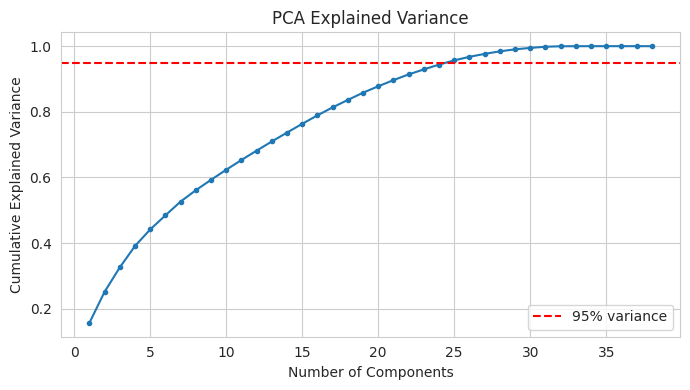

Components needed for 95% variance: 25 out of 38


In [22]:
from sklearn.decomposition import PCA

pca_check = PCA().fit(X_train_res)
explained = np.cumsum(pca_check.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(range(1, len(explained)+1), explained, marker='o', markersize=3)
ax.axhline(0.95, color='red', linestyle='--', label='95% variance')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Explained Variance')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/pca_explained_variance.png', dpi=120)
plt.show()

n_95 = np.argmax(explained >= 0.95) + 1
print(f'Components needed for 95% variance: {n_95} out of {X_train_res.shape[1]}')

## 8. Train Multiple Models

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=6),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10),
    'SVM': SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                              random_state=42, eval_metric='logloss'),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='f1')
    cv_results[name] = scores
    print(f'{name:22s} F1: {scores.mean():.4f} (+/- {scores.std():.4f})')

Logistic Regression    F1: 0.7304 (+/- 0.0456)
Decision Tree          F1: 0.7445 (+/- 0.0386)


Random Forest          F1: 0.8190 (+/- 0.0290)


SVM                    F1: 0.7645 (+/- 0.0123)


XGBoost                F1: 0.8291 (+/- 0.0303)


In [24]:
# Fit each model on the full (SMOTE-resampled) training set
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    fitted_models[name] = model
print('All models fitted.')

All models fitted.


## 9. Model Evaluation

In [25]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

results = []
for name, model in fitted_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.810811,0.851240,0.858333,0.854772,0.864615
1,Random Forest,0.772973,0.809524,0.850000,0.829268,0.837821
2,Decision Tree,0.751351,0.803279,0.816667,0.809917,0.700833
3,Logistic Regression,0.745946,0.876289,0.708333,0.783410,0.803974
4,SVM,0.708108,0.811321,0.716667,0.761062,0.770769


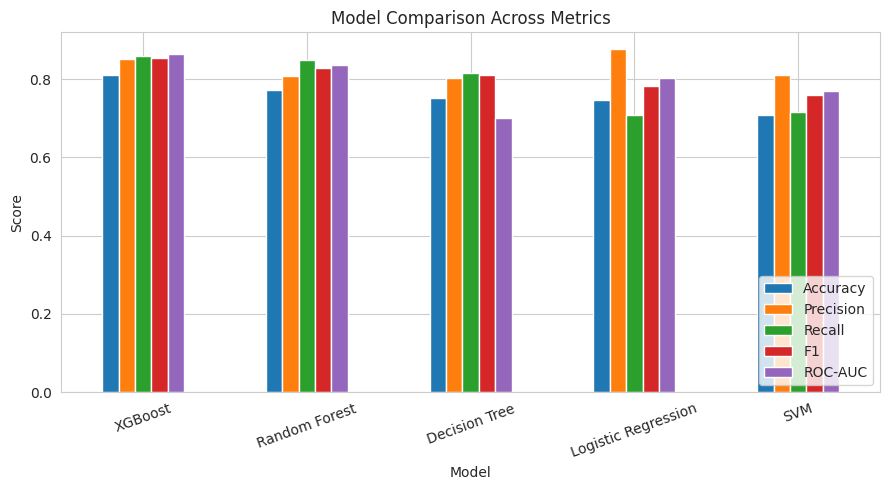

In [26]:
fig, ax = plt.subplots(figsize=(9,5))
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1','ROC-AUC']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison Across Metrics')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../notebooks/model_comparison.png', dpi=120)
plt.show()

In [27]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
print(f'Best model: {best_model_name}')

y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=['Closed','Acquired']))

Best model: XGBoost
              precision    recall  f1-score   support

      Closed       0.73      0.72      0.73        65
    Acquired       0.85      0.86      0.85       120

    accuracy                           0.81       185
   macro avg       0.79      0.79      0.79       185
weighted avg       0.81      0.81      0.81       185



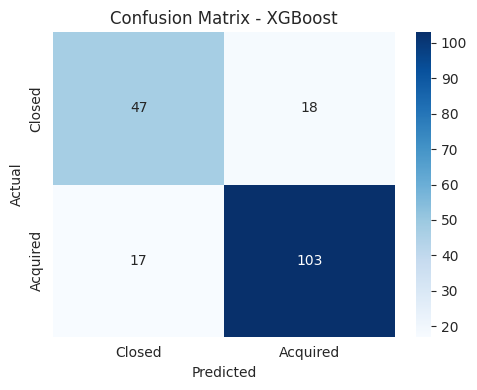

In [28]:
fig, ax = plt.subplots(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Closed','Acquired'], yticklabels=['Closed','Acquired'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrix_best.png', dpi=120)
plt.show()

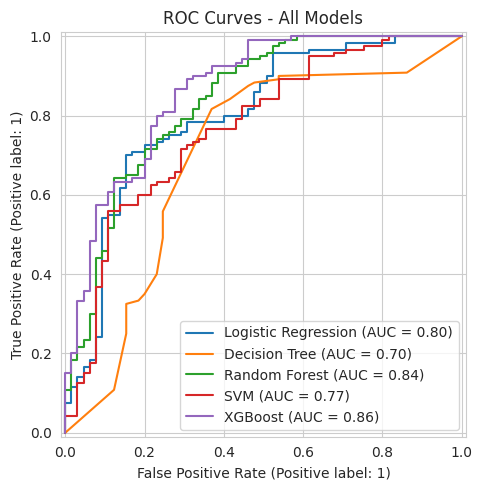

In [29]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6,5))
for name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
ax.set_title('ROC Curves - All Models')
plt.tight_layout()
plt.savefig('../notebooks/roc_curves.png', dpi=120)
plt.show()

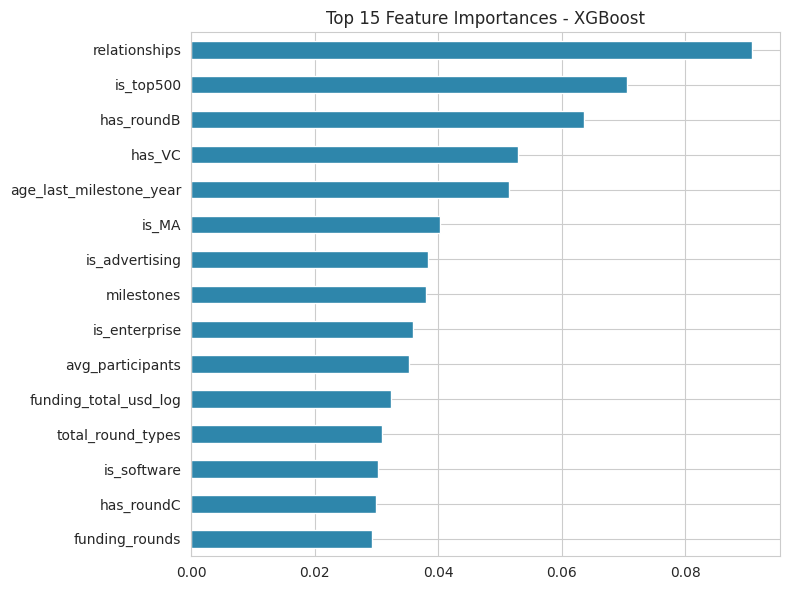

In [30]:
# Feature importance from the best tree-based model (or coefficient magnitude for linear models)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
elif hasattr(best_model, 'coef_'):
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X_train.columns).sort_values(ascending=False)
else:
    importances = None

if importances is not None:
    fig, ax = plt.subplots(figsize=(8,6))
    importances.head(15).plot(kind='barh', ax=ax, color='#2E86AB')
    ax.invert_yaxis()
    ax.set_title(f'Top 15 Feature Importances - {best_model_name}')
    plt.tight_layout()
    plt.savefig('../notebooks/feature_importance.png', dpi=120)
    plt.show()
else:
    print(f'{best_model_name} does not expose feature importances directly (e.g. SVM with RBF kernel).')

## 10. Save the Best Model

In [31]:
import joblib

joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X.columns), '../models/feature_columns.pkl')

print(f'Saved: {best_model_name} -> ../models/best_model.pkl')
print(f'Saved: scaler -> ../models/scaler.pkl')
print(f'Saved: feature columns -> ../models/feature_columns.pkl')

Saved: XGBoost -> ../models/best_model.pkl
Saved: scaler -> ../models/scaler.pkl
Saved: feature columns -> ../models/feature_columns.pkl
